# Dataset Description


Dataset source:

https://www.kaggle.com/datasets/hari31416/world-happiness-report/data
The datasets belong to the field of social and economic statistics.

They contain annual data for multiple countries from 2015 to 2022 and include indicators such as economic conditions (GDP per capita), social support (Family), healthy life expectancy (Health), freedom to make life choices (Freedom), generosity, trust in institutions, and overall happiness scores.

For further analysis, the datasets will be merged into a single table using the additional **Year** column, which allows matching records from different years and enables time-series analysis.

In [81]:
import pandas as pd

In [82]:
tables = []
years = range(2015, 2023)

for year in years:
    table = pd.read_csv(f"../data_sets/{year}.csv")
    table["Year"] = year
    tables.append(table)


Before merging the datasets, it is needed to examine their structure and verify whether the columns are consistent across all years.

In [83]:
reference_year = tables[0]


for i in range(len(tables)):
    if tables[i].columns.equals(reference_year.columns):
        print(f"{years[i]}: equal")
    else:
        print(f"{years[i]}: {set(tables[i].columns)^set(reference_year.columns)}")

2015: equal
2016: equal
2017: equal
2018: {'Dystopia'}
2019: {'Dystopia'}
2020: equal
2021: equal
2022: equal


The comparison of column names showed that the datasets do not have completely identical structures: the datasets for 2018 and 2019 do not contain the Dystopia column, while all other years include it.

Since the purpose of this project is to analyze variables that are available for every year, the datasets will be combined using only the columns that are present in all tables.

In [84]:
all_data = pd.concat(tables, axis = 0, join = 'inner', ignore_index = True)

In [85]:
all_data.head()

,Country,Region,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Trust,Year
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015


In [86]:
all_data.shape

(1185, 11)

In [87]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185 entries, 0 to 1184
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          1185 non-null   object 
 1   Region           1185 non-null   object 
 2   Happiness Rank   1185 non-null   int64  
 3   Happiness Score  1185 non-null   float64
 4   Economy          1185 non-null   float64
 5   Family           1185 non-null   float64
 6   Health           1185 non-null   float64
 7   Freedom          1185 non-null   float64
 8   Generosity       1185 non-null   float64
 9   Trust            1184 non-null   float64
 10  Year             1185 non-null   int64  
dtypes: float64(7), int64(2), object(2)
memory usage: 102.0+ KB


The merged dataset contains 1185 rows and 11 fields. The fields are represented by the following data types:
- 2 categorical fields (object): Country, Region
- 2 integer numerical fields (int64): Happiness Rank, Year
- 7 continuous numerical fields (float64): Happiness Score, Economy, Family, Health, Freedom, Generosity, Trust

In [88]:
all_data.isna().sum()

Country            0
Region             0
Happiness Rank     0
Happiness Score    0
Economy            0
Family             0
Health             0
Freedom            0
Generosity         0
Trust              1
Year               0
dtype: int64

In [89]:
all_data.duplicated().sum()

np.int64(0)

The dataset is generally of high quality.

* No duplicate rows were found in the dataset.
* Only one missing value was detected in the `Trust` column, while all other fields were complete.
* The data types of all columns were examined and found to be appropriate for their contents: categorical variables are stored as `object`, numerical indicators as `float64`, and ranking and year values as `int64`. No inconsistent values or data type issues were
 identified yet.

 Therefore, the dataset can be considered clean and suitable for further analysis.


# Descriptive statistics

In [90]:
statistics_h = pd.DataFrame ({

    "Mean":[
    all_data["Happiness Score"].mean(),
    all_data["Economy"].mean(),
    all_data["Family"].mean(),
    all_data["Health"].mean(),
    all_data["Freedom"].mean(),
    all_data["Generosity"].mean(),
    all_data["Trust"].mean()],

    "Median": [
    all_data["Happiness Score"].median(),
    all_data["Economy"].median(),
    all_data["Family"].median(),
    all_data["Health"].median(),
    all_data["Freedom"].median(),
    all_data["Generosity"].median(),
    all_data["Trust"].median()],

    "Standard Deviation": [
    all_data["Happiness Score"].std(),
    all_data["Economy"].std(),
    all_data["Family"].std(),
    all_data["Health"].std(),
    all_data["Freedom"].std(),
    all_data["Generosity"].std(),
    all_data["Trust"].std()],

    "Minimum": [
    all_data["Happiness Score"].min(),
    all_data["Economy"].min(),
    all_data["Family"].min(),
    all_data["Health"].min(),
    all_data["Freedom"].min(),
    all_data["Generosity"].min(),
    all_data["Trust"].min()],

    "Maximum": [
    all_data["Happiness Score"].max(),
    all_data["Economy"].max(),
    all_data["Family"].max(),
    all_data["Health"].max(),
    all_data["Freedom"].max(),
    all_data["Generosity"].max(),
    all_data["Trust"].max()],
},

index = ["The happiness score on a scale from 0 to 10",
         "The GDP per capita index", "Social Support",
         "Healthy Life Expectancy",
         "Freedom to make life choices",
         "Generosity in the community",
         "Trust in government"]
)

statistics_h

,Mean,Median,Standard Deviation,Minimum,Maximum
The happiness score on a scale from 0 to 10,5.450030,5.440000,1.112219,2.404000,7.842000
The GDP per capita index,3.125965,1.219000,3.716801,0.000000,11.647000
Social Support,0.996089,0.950000,0.305360,0.000000,1.644000
Healthy Life Expectancy,16.952080,0.739000,28.161788,0.000000,76.953000
Freedom to make life choices,0.518994,0.512310,0.215724,0.000000,0.974998
Generosity in the community,0.152385,0.155000,0.162013,-0.300907,0.838075
Trust in government,0.282649,0.135045,0.292672,0.000000,0.939000


The descriptive statistics provide a general overview of the dataset and the distribution of its main numerical variables. Most indicators have reasonable ranges and average values that correspond to the expected scale of the World Happiness Report data.

However, the summary statistics also revealed potential inconsistencies in some variables. In particular, certain indicators show unusually large differences between their average values, medians, and maximum values, which may indicate that different measurement scales were used across parts of the dataset. These discrepancies will be investigated in more detail during the Data Cleanup stage, where the data will be checked for inconsistencies and, if necessary, standardized before further analysis.


# Data cleanup

During the initial exploration of the dataset, several data quality issues were identified:

* First, one missing value was found in the `Trust` column, while all other fields were complete.
* Second, the descriptive statistics revealed unusually large standard deviations and extreme values in the `Health` and `Economy` indicators.

These results suggest the presence of inconsistencies in the data, possibly caused by differences in measurement scales across years.

To ensure the reliability of further analysis, these issues will be investigated and addressed in the Data Cleanup stage. Missing values will be handled appropriately, and the identified inconsistencies will be examined and corrected where necessary.


In [91]:
all_data = all_data.dropna()
all_data.isna().sum()

Country            0
Region             0
Happiness Rank     0
Happiness Score    0
Economy            0
Family             0
Health             0
Freedom            0
Generosity         0
Trust              0
Year               0
dtype: int64

In [92]:
all_data.groupby("Year")["Health"].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2015,158.0,0.630259,0.247078,0.000000,0.439185,0.696705,0.811013,1.025250
2016,157.0,0.557619,0.229349,0.000000,0.382910,0.596590,0.729930,0.952770
2017,150.0,0.557302,0.226623,0.005565,0.398654,0.609627,0.717596,0.949492
2018,150.0,0.605207,0.240166,0.000000,0.430000,0.651000,0.779750,1.030000
2019,148.0,0.739554,0.226197,0.192000,0.567000,0.796500,0.885750,1.141000
2020,153.0,64.445529,7.057848,45.200001,58.961712,66.305145,69.289192,76.804581
2021,149.0,64.992799,6.762043,48.478000,59.802000,66.603000,69.600000,76.953000
2022,119.0,0.609193,0.156104,0.270000,0.516000,0.633000,0.731500,0.866000


In [93]:
all_data.groupby("Year")["Economy"].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2015,158.0,0.846137,0.403121,0.000000,0.545808,0.910245,1.158448,1.690420
2016,157.0,0.953880,0.412595,0.000000,0.670240,1.027800,1.279640,1.824270
2017,150.0,0.992605,0.409519,0.022643,0.718908,1.066948,1.315027,1.870766
2018,150.0,0.892160,0.372945,0.000000,0.644500,0.949500,1.185000,1.649000
2019,148.0,0.918162,0.391510,0.000000,0.636250,0.972500,1.237250,1.684000
2020,153.0,9.295706,1.201588,6.492642,8.350645,9.456313,10.265124,11.450681
2021,149.0,9.432208,1.158601,6.635000,8.541000,9.569000,10.421000,11.647000
2022,119.0,1.449403,0.394815,0.000000,1.187500,1.459000,1.798500,2.149000


In [94]:
all_data = all_data.drop(columns=["Health", "Economy"])
all_data.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Family',
       'Freedom', 'Generosity', 'Trust', 'Year'],
      dtype='object')

In [95]:
all_data

,Country,Region,Happiness Rank,Happiness Score,Family,Freedom,Generosity,Trust,Year
0,Switzerland,Western Europe,1,7.587,1.34951,0.66557,0.29678,0.41978,2015
1,Iceland,Western Europe,2,7.561,1.40223,0.62877,0.43630,0.14145,2015
2,Denmark,Western Europe,3,7.527,1.36058,0.64938,0.34139,0.48357,2015
3,Norway,Western Europe,4,7.522,1.33095,0.66973,0.34699,0.36503,2015
4,Canada,North America,5,7.427,1.32261,0.63297,0.45811,0.32957,2015
...,...,...,...,...,...,...,...,...,...
1180,Tanzania,Sub-Saharan Africa,139,3.702,0.59700,0.57800,0.24800,0.27000,2022
1181,Sierra Leone,Sub-Saharan Africa,140,3.574,0.41600,0.38700,0.20200,0.05500,2022
1182,Zimbabwe,Sub-Saharan Africa,144,2.995,0.69000,0.32900,0.10600,0.10500,2022
1183,Lebanon,Middle East and Northern Africa,145,2.955,0.49800,0.10300,0.08200,0.03400,2022


During the data cleaning process, one row containing a missing value in the Trust column was removed.

Further investigation revealed that the Health and Economy indicators were reported on substantially different scales in some years. Since no reliable conversion method was available and these variables were not essential for the subsequent analysis, they were removed from the dataset to ensure consistency.

# Plots

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt
import streamlit as st

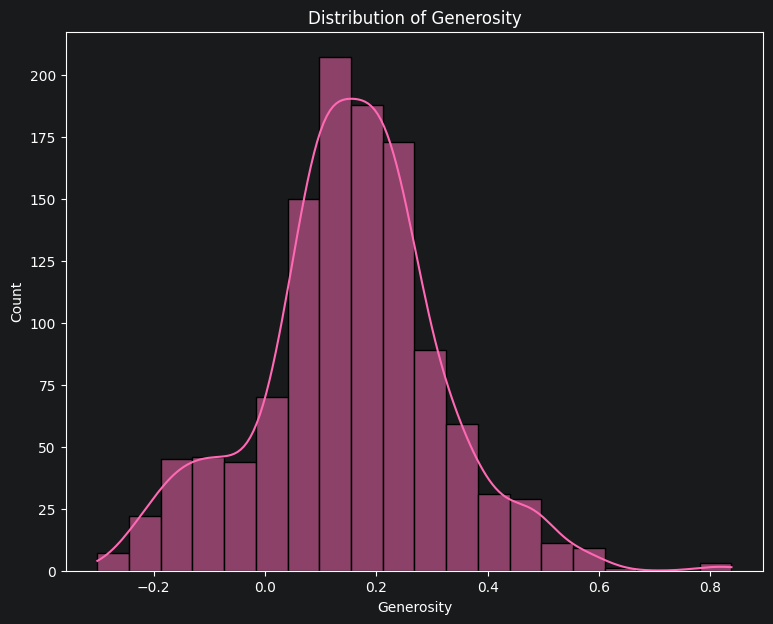

In [97]:
plt.figure(figsize=(9,7))

sns.histplot(
    data=all_data,
    x="Generosity",
    bins=20,
    kde=True,
    color = "#FF69B4"
)

plt.title("Distribution of Generosity")
plt.xlabel("Generosity")
plt.ylabel("Count")

plt.show()

##### The histogram shows the distribution of the Generosity indicator across all countries and years included in the dataset.
 The distribution is right-skewed, with most values concentrated between -0.2 and 0.4, and a long tail extending toward higher values. This suggests that while most countries report relatively low or moderate levels of generosity, a smaller number of countries stand out with noticeably higher scores.

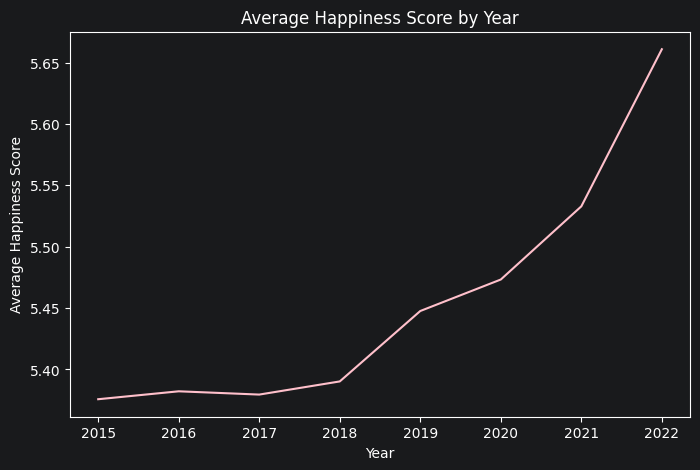

In [98]:
mean_happiness = (
    all_data.groupby("Year")["Happiness Score"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))

sns.lineplot(
    data=mean_happiness,
    x="Year",
    y="Happiness Score",
    color = "pink"
)

plt.title("Average Happiness Score by Year")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")

plt.show()

##### The line plot displays the trend in average Happiness Score from 2015 to 2022.
 The average score remains relatively stable, fluctuating between approximately 5.4 and 5.5 from 2015 to 2019. A noticeable drop occurs in 2020, falling below 5.2. In 2021–2022, the values show a partial recovery.